In [1]:
#importing useful python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
# Sklearn tools
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
#from sklearn.model_selection import cross_val_score

# XGBoost
from xgboost import XGBClassifier

In [2]:
# dataset
positives=pd.read_csv('lightcurve_features_26.csv')
negatives=pd.read_csv('lightcurve_features_26_negative.csv')

In [3]:
combined = pd.concat([positives,negatives])
# Shuffle the combined dataset
#combined = combined.sample(frac=1)#.reset_index(drop=True)
combined.to_parquet("biggie_set_with_all_neg_and_pos.parquet", index=False)

print("Combined and shuffled dataset saved")
print("Total rows:", len(combined))

Combined and shuffled dataset saved
Total rows: 1610


In [4]:
x=1471+139
print('x=',x)

x= 1610


In [5]:
df=pd.read_parquet("biggie_set_with_all_neg_and_pos.parquet")

In [18]:
df

,object,mean,weighted_mean,standard_deviation,median,amplitude,beyond_1_std,cusum,inter_percentile_range_10,kurtosis,...,magnitude_percentage_ratio_20_10,maximum_slope,median_absolute_deviation,median_buffer_range_percentage_10,percent_amplitude,mean_variance,anderson_darling_normal,chi2,skew,stetson_K
0,V479 And,17.268163,17.236716,0.180454,17.273849,0.666252,0.328125,0.069825,0.460431,-0.035883,...,0.675921,1047.466565,0.125532,0.280777,0.733604,0.010450,2.085659,94.693020,-0.271274,0.798775
1,V1309 Ori,15.720073,15.634069,0.449468,15.607049,1.007579,0.246479,0.091691,1.249109,0.613096,...,0.504922,183.955383,0.220738,0.232394,1.347842,0.028592,30.141442,1144.025302,1.107530,0.780070
2,AI Tri,16.339606,16.129012,0.641042,16.161560,1.392405,0.314172,0.314640,1.735063,-0.395987,...,0.668416,210.960538,0.373932,0.203171,1.838871,0.039232,25.523250,1301.845213,0.746145,0.831868
3,MQ Dra,17.466180,17.337143,0.364589,17.434200,0.712118,0.456381,0.050537,0.961357,-1.401971,...,0.821901,188.001161,0.332115,0.095890,0.720089,0.020874,34.268952,309.597087,0.125844,0.896494
4,J2048+0050,18.698472,18.666318,0.148085,18.703554,0.457648,0.323529,0.235844,0.393805,-0.192066,...,0.649716,187.900246,0.099949,0.237395,0.486221,0.007920,0.486493,11.527544,-0.182791,0.806461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,ZTF18abgzjck,16.654061,16.651763,0.078853,16.664974,0.399733,0.314956,0.364285,0.193176,0.520959,...,0.767738,335.216219,0.059408,0.280022,0.533226,0.004735,31.846293,15.583201,-0.274010,0.841964
1606,ZTF18abhfdox,15.672581,15.664374,0.203161,15.629044,0.554236,0.506274,0.385983,0.512150,-1.164869,...,0.816458,287.392110,0.185408,0.213857,0.662415,0.012963,59.871746,125.542405,-0.046043,0.869043
1607,ZTF18abicwzl,16.171780,16.166272,0.142373,16.176975,0.586526,0.268791,0.184090,0.350670,1.280258,...,0.537875,491.297072,0.053593,0.511726,0.594362,0.008804,32.393939,54.299823,-0.218692,0.691085
1608,ZTF18abjaptb,16.285811,16.279300,0.135786,16.318378,0.903792,0.251357,0.251233,0.308055,6.857478,...,0.602996,847.689328,0.054186,0.615092,1.378195,0.008338,41.680390,58.524971,0.347693,0.771556


In [6]:
#X
X = df.drop(columns=['object']).values

In [7]:
# object column contains names like 'ZTF18abc...' or non-ZTF names : Binary conversion of objects
y = np.where(df['object'].str.contains('ZTF', case=False),
             -1,   # ZTF → negative
              1)   # non-ZTF → positive

In [8]:
print(np.unique(y))


[-1  1]


In [9]:
#doing this as XGBBOOST can't deal with -1 and 1
y[y == -1] = 0


In [10]:
print(np.unique(y))


[0 1]


In [25]:
# Best hyperparameters
train_size = 0.70
n_estimators = 130

# Final train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.70,
    shuffle=True,
    #random_state=42
)

# Train final model
final_model =  XGBClassifier(
    n_estimators=130,
    n_jobs=-1,
    learning_rate=0.1, #Learning rate shrinks the contribution of each tree,Values must be in the range [0.0, inf),values by default float, default=0.1
    max_depth=3, #max_depthint or None, default=3
    eval_metric='logloss' 
)

final_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [26]:
#training set
final_model.fit(X_train, y_train)

print("Model trained successfully")


Model trained successfully


In [27]:
#predict model
y_pred = xgb_model.predict(X_test)
print(y_pred)


[0 0 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [28]:
#accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9958592132505176


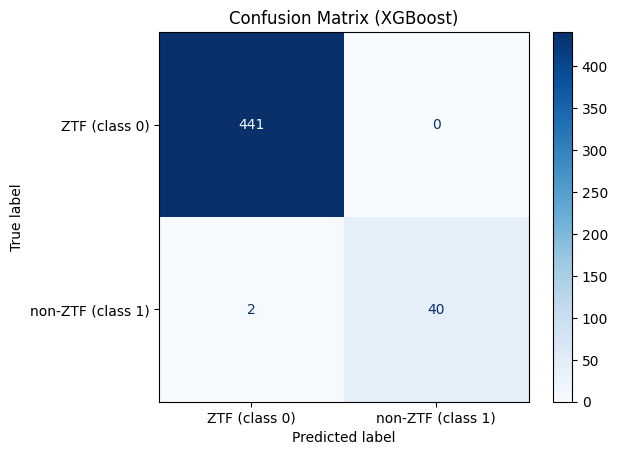

In [29]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

class_names = ["ZTF (class 0)", "non-ZTF (class 1)"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (XGBoost)")
plt.show()

In [17]:
#extract TP, TN, FP, FN
TN, FP, FN, TP = cm.ravel()
print("TN:", TN, "FP:", FP, "FN:", FN, "TP:", TP)

TN: 443 FP: 2 FN: 10 TP: 28


In [ ]:
#saving the final model
joblib.dump(final_model, "cv_classifier_xgb_boost.pkl")